# How are in-demand skills trending for Data Analyst?

## Steps:

1. Aggregate skill counts monthly
2. Re-analyze based on percentage of total jobs
3. Plot the monthly skill demand

In [1]:
#Importing Libraries
import pandas as pd
import matplotlib.pyplot as plt
import ast
import seaborn as sns
from datasets import load_dataset

#Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [2]:
df_DA_Countries = df[(df['job_country'].isin(['United States', 'Mexico', 'Germany', 'UK']))].copy()

In [3]:
df_DA_Countries['job_posted_month_no'] = df_DA_Countries['job_posted_date'].dt.month
#df_DA_Countries

In [4]:
df_DA_Countries_explode = df_DA_Countries.explode('job_skills')

In [5]:
df_pivot = df_DA_Countries_explode.pivot_table(index='job_posted_month_no', columns='job_skills', aggfunc='size', fill_value=0)
df_pivot.loc['Total'] = df_pivot.sum()
df_pivot = df_pivot[df_pivot.loc['Total'].sort_values(ascending=False).index]
df_pivot = df_pivot.drop('Total')
#df_pivot

In [6]:
data_totals = df_DA_Countries.groupby('job_posted_month_no').size()

In [7]:
df_percent = df_pivot.div(data_totals/100, axis=0)
#df_percent

In [8]:
df_percent = df_percent.reset_index()
df_percent['job_posted_month'] = df_percent['job_posted_month_no'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b'))
df_percent = df_percent.set_index('job_posted_month')
df_percent = df_percent.drop(columns='job_posted_month_no')
df_percent

job_skills,sql,python,r,tableau,excel,aws,sas,spark,azure,power bi,...,huggingface,capacitor,asp.netcore,kali,gtx,ocaml,msaccess,microsoft lists,nuxt.js,wimi
job_posted_month,,,,,,,,,,,,,,,,,,,,,
Jan,55.854518,52.172945,26.594916,23.499722,22.304695,17.439228,18.385600,14.581555,12.859529,11.887178,...,0.000000,0.003711,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Feb,55.389935,52.348021,23.793281,23.111070,21.372833,19.148638,16.700154,15.536657,14.120835,12.457362,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Mar,54.779919,51.834404,24.363550,23.035927,21.384725,19.367119,17.463716,14.865572,13.980490,12.205567,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Apr,55.434783,52.461783,24.166170,23.714513,21.873139,18.681755,17.421084,14.453047,13.956720,12.934286,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
May,56.463125,54.491900,24.606322,24.062535,20.425966,19.542313,17.038631,15.503569,14.784185,13.498357,...,0.000000,0.000000,0.005664,0.000000,0.000000,0.000000,0.005664,0.000000,0.000000,0.000000
Jun,55.547717,52.685680,24.014915,23.118009,20.946286,18.638517,15.932682,14.864456,14.773758,13.811347,...,0.000000,0.000000,0.000000,0.010078,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Jul,54.267195,52.698184,24.065024,23.627759,20.093626,18.642934,15.957611,14.182828,14.074798,13.462627,...,0.005144,0.005144,0.000000,0.000000,0.005144,0.000000,0.000000,0.000000,0.000000,0.000000
Aug,55.531175,53.241699,25.341558,23.437112,20.886810,17.653391,16.568684,13.993541,13.082719,13.140681,...,0.000000,0.000000,0.004140,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Sep,51.196124,49.647905,20.201768,20.096889,18.603606,17.929381,14.483344,13.814114,14.792988,12.290866,...,0.009989,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


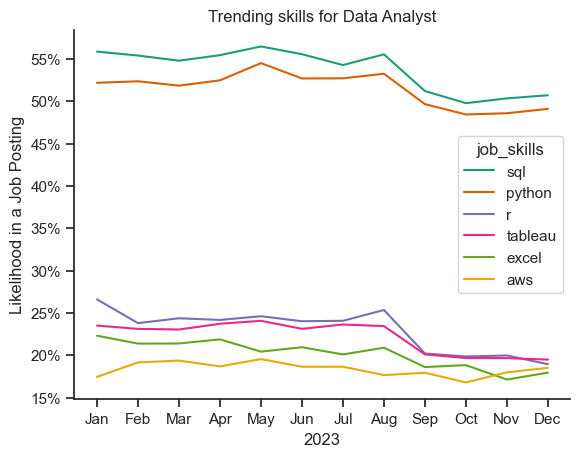

In [9]:
df_plot = df_percent.iloc[:, :6]

sns.set_theme(style='ticks')
sns.lineplot(data=df_plot, dashes=False, palette='Dark2')
sns.despine()
plt.title('Trending skills for Data Analyst')
plt.xlabel('2023')
plt.ylabel('Likelihood in a Job Posting')
#plt.legend().remove()

#Setting up decimals for the y axis
from matplotlib.ticker import PercentFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(PercentFormatter(decimals=0))

#Giving text to each line, to see what skill it is
#for i in range(6):
    #plt.text(11.5, df_plot.iloc[-1, i], df_plot.columns[i])